In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

DATA_PATH = Path("../data")

movies = pd.read_csv(DATA_PATH / "movies.csv")
ratings = pd.read_csv(DATA_PATH / "ratings.csv")

In [27]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [28]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [29]:
print("Número de filmes:", movies.shape[0])
print("Número de avaliações:", ratings.shape[0])
print("Número de usuários:", ratings["userId"].nunique())

Número de filmes: 9742
Número de avaliações: 100836
Número de usuários: 610


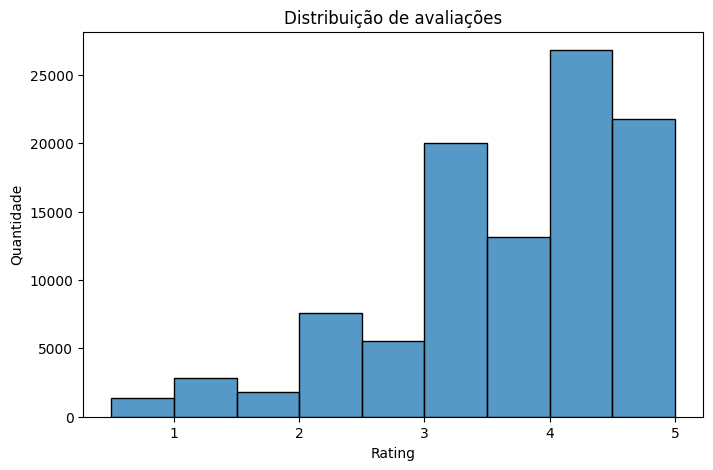

In [30]:
plt.figure(figsize = (8, 5))
sns.histplot(ratings["rating"], bins = 9)
plt.title("Distribuição de avaliações")
plt.xlabel("Rating")
plt.ylabel("Quantidade")
plt.show()

In [31]:
movie_ratings = ratings.groupby("movieId").size()

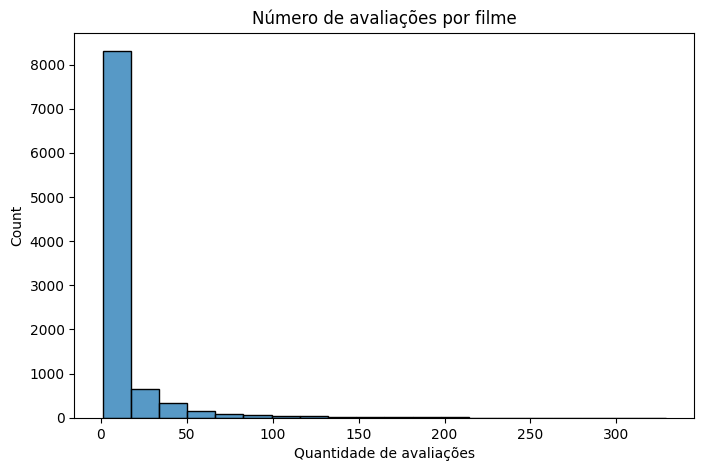

In [32]:
plt.figure(figsize = (8, 5))
sns.histplot(movie_ratings, bins = 20)
plt.title("Número de avaliações por filme")
plt.xlabel("Quantidade de avaliações")
plt.show()

In [33]:
top_movies = movie_ratings.sort_values(ascending = False).head(10)

top_movies

movieId
356     329
318     317
296     307
593     279
2571    278
260     251
480     238
110     237
589     224
527     220
dtype: int64

In [34]:
top_movies = top_movies.reset_index()
top_movies = top_movies.merge(movies, on = "movieId")

top_movies[["title", 0]]

,title,0
0,Forrest Gump (1994),329
1,"Shawshank Redemption, The (1994)",317
2,Pulp Fiction (1994),307
3,"Silence of the Lambs, The (1991)",279
4,"Matrix, The (1999)",278
5,Star Wars: Episode IV - A New Hope (1977),251
6,Jurassic Park (1993),238
7,Braveheart (1995),237
8,Terminator 2: Judgment Day (1991),224
9,Schindler's List (1993),220


In [37]:
genres = movies["genres"].str.split("|")
genres = genres.explode()

In [38]:
genre_counts = genres.value_counts()

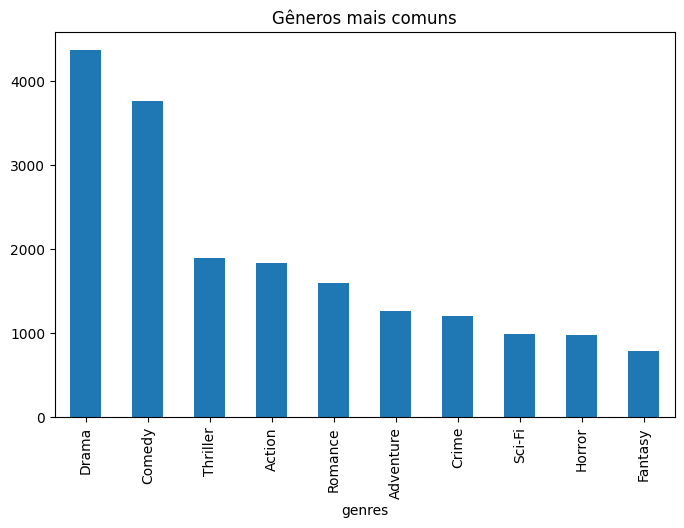

In [40]:
plt.figure(figsize = (8, 5))
genre_counts.head(10).plot(kind = "bar")
plt.title("Gêneros mais comuns")
plt.show()

In [41]:
movie_stats =  ratings.groupby("movieId").agg(
  avg_ratings = ("rating", "mean"),
  num_ratings = ("rating", "count")
)

movie_stats.head()

,avg_ratings,num_ratings
movieId,,
1,3.920930,215
2,3.431818,110
3,3.259615,52
4,2.357143,7
5,3.071429,49
